In [1]:
import matplotlib.pyplot as plt
import pathlib, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout , GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint

In [2]:
train_path="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
no_birds_classes = os.listdir(train_path)
len(no_birds_classes)

41

In [3]:
data_dir = pathlib.Path("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\")
BirdClasses = np.array(([item.name for item in data_dir.glob("*")]))
print(BirdClasses)

['babblers bird' 'barbets bird' 'bulbuls bird' 'coots bird' 'cranes bird'
 'cuckoos bird' 'Doves bird' 'Drongos bird' 'Ducks bird' 'Eagles bird'
 'Egrets bird' 'Falcons bird' 'Finches bird' 'Flycatchers bird'
 'Herons bird' 'Hornbills bird' 'Jacanas bird' 'kingfishers bird'
 'munias bird' 'nightjars bird' 'orioles bird' 'owls bird'
 'parakeets bird' 'peafowl bird' 'pesants bird' 'pigeons bird'
 'plovers bird' 'prinias bird' 'robins bird' 'sandpipers bird'
 'shrikes bird' 'storks bird' 'sunbirds bird' 'swallows bird'
 'swamphens bird' 'swifts bird' 'terns bird' 'tits bird' 'wagtails bird'
 'warblers bird' 'woodpeckers bird']


# visualising the images

In [4]:
def view_random_image(target_dir, target_class):
  
  # setting up the image directory
  target_folder = target_dir +'\\' + target_class

  #get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  #read image and plotting it
  img = plt.imread(target_folder + "\\" + random_image[0] )
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  #print(f"Image shape: {img.shape}")
  
  return img

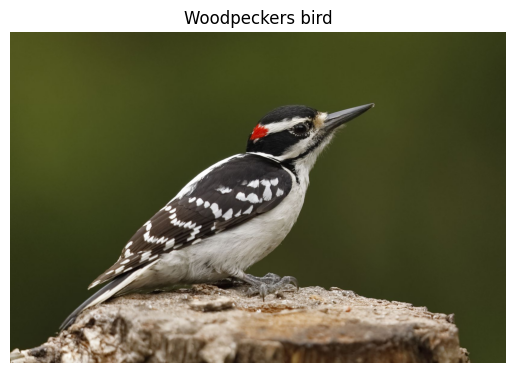

In [5]:
img = view_random_image(train_path,'Woodpeckers bird')

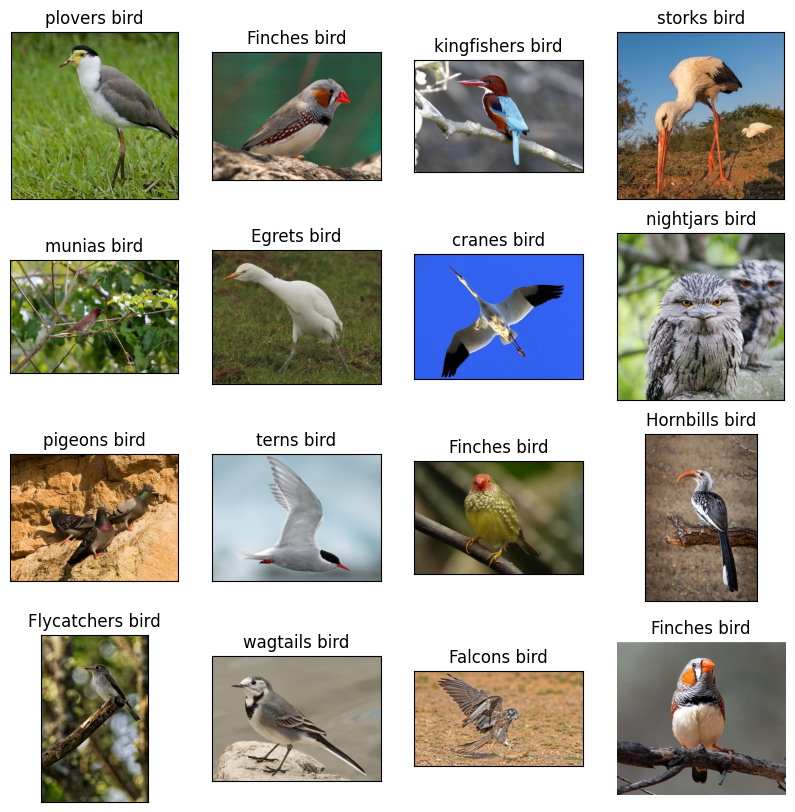

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

random_index = np.random.randint(0 , len(BirdClasses)-1 , 16)

for i, ax in enumerate(axes.flat):
    ax.imshow(view_random_image(train_path,BirdClasses[random_index[i]]))
    ax.set_title(BirdClasses[random_index[i]])

# data preprocessing 

In [7]:
train_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
test_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\test\\"
val_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\val\\"

In [8]:
from keras.applications.mobilenet_v2 import MobileNetV2

In [9]:
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory( train_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=True )

val_data = val_gen.flow_from_directory( val_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" , shuffle=True )

test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=False )

Found 4303 images belonging to 41 classes.
Found 902 images belonging to 41 classes.
Found 942 images belonging to 41 classes.


# Preparing MobileNet Pretrained Model

In [10]:
mobilenet = tf.keras.applications.resnet.ResNet152( include_top=False , weights="imagenet" , input_shape=(224,224,3))

mobilenet.summary()

Model: "resnet152"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                          

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 56, 56, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 56, 56, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block6_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block6_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block6_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block6_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block6_3_conv (Conv2D)   (None, 28, 28, 512)  66048       ['conv3_block6_2_relu[0][0]']    
                                                                                                  
 conv3_block6_3_bn (BatchNormal  (None, 28, 28, 512)  2048       ['conv3_block6_3_conv[0][0]']    
 ization) 

 n)                                                                                               
                                                                                                  
 conv4_block1_0_conv (Conv2D)   (None, 14, 14, 1024  525312      ['conv3_block8_out[0][0]']       
                                )                                                                 
                                                                                                  
 conv4_block1_3_conv (Conv2D)   (None, 14, 14, 1024  263168      ['conv4_block1_2_relu[0][0]']    
                                )                                                                 
                                                                                                  
 conv4_block1_0_bn (BatchNormal  (None, 14, 14, 1024  4096       ['conv4_block1_0_conv[0][0]']    
 ization)                       )                                                                 
          

...

                                                                                                  
 conv4_block28_1_conv (Conv2D)  (None, 14, 14, 256)  262400      ['conv4_block27_out[0][0]']      
                                                                                                  
 conv4_block28_1_bn (BatchNorma  (None, 14, 14, 256)  1024       ['conv4_block28_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block28_1_relu (Activati  (None, 14, 14, 256)  0          ['conv4_block28_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block28_2_conv (Conv2D)  (None, 14, 14, 256)  590080      ['conv4_block28_1_relu[0][0]']   
          

                                )                                                                 
                                                                                                  
 conv4_block31_1_conv (Conv2D)  (None, 14, 14, 256)  262400      ['conv4_block30_out[0][0]']      
                                                                                                  
 conv4_block31_1_bn (BatchNorma  (None, 14, 14, 256)  1024       ['conv4_block31_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block31_1_relu (Activati  (None, 14, 14, 256)  0          ['conv4_block31_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_blo

 conv4_block33_out (Activation)  (None, 14, 14, 1024  0          ['conv4_block33_add[0][0]']      
                                )                                                                 
                                                                                                  
 conv4_block34_1_conv (Conv2D)  (None, 14, 14, 256)  262400      ['conv4_block33_out[0][0]']      
                                                                                                  
 conv4_block34_1_bn (BatchNorma  (None, 14, 14, 256)  1024       ['conv4_block34_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block34_1_relu (Activati  (None, 14, 14, 256)  0          ['conv4_block34_1_bn[0][0]']     
 on)                                                                                              
          

                                                                                                  
 conv4_block36_out (Activation)  (None, 14, 14, 1024  0          ['conv4_block36_add[0][0]']      
                                )                                                                 
                                                                                                  
 conv5_block1_1_conv (Conv2D)   (None, 7, 7, 512)    524800      ['conv4_block36_out[0][0]']      
                                                                                                  
 conv5_block1_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block1_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block1_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block1_1_bn[0][0]']      
 n)       

                                                                  'conv5_block3_3_bn[0][0]']      
                                                                                                  
 conv5_block3_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block3_add[0][0]']       
                                                                                                  
Total params: 58,370,944
Trainable params: 58,219,520
Non-trainable params: 151,424
__________________________________________________________________________________________________


# Fine-Tuning MobileNet Model

In [11]:
# Freezing all layers except the last 20 layers

mobilenet.trainable=True
"""
for layer in mobilenet.layers[:-20]:
  layer.trainable=False
"""

'\nfor layer in mobilenet.layers[:-20]:\n  layer.trainable=False\n'

In [12]:
Model = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256,activation='relu'),
    BatchNormalization(),
    Dense(41,activation='softmax')
])

Model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet152 (Functional)      (None, 7, 7, 2048)        58370944  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                        

In [13]:
#Model.compile( optimizer="adam", loss="categorical_crossentropy" , metrics=["accuracy"] )
Model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True),
               loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [14]:
# Create Callback Checkpoint

#checkpoint_path = "BirdsSpecies_Model_Checkpoint"
#checkpoint_callback = ModelCheckpoint(checkpoint_path,monitor="val_accuracy",save_best_only=True)

callbacks = [EarlyStopping(monitor='val_accuracy' , patience=5 , restore_best_weights=True)]

In [15]:
history = Model.fit(train_data,epochs=50,batch_size=32 ,steps_per_epoch = len(train_data)
,callbacks=callbacks , validation_data=val_data,validation_steps = len(val_data))

Epoch 1/50
135/135 [==============================] - 208s 1s/step - loss: 2.0652 - accuracy: 0.4769 - val_loss: 7.6804 - val_accuracy: 0.0244
Epoch 2/50
135/135 [==============================] - 133s 982ms/step - loss: 0.3639 - accuracy: 0.9233 - val_loss: 6.0556 - val_accuracy: 0.0266
Epoch 3/50
135/135 [==============================] - 130s 961ms/step - loss: 0.1005 - accuracy: 0.9935 - val_loss: 4.5271 - val_accuracy: 0.0322
Epoch 4/50
135/135 [==============================] - 141s 1s/step - loss: 0.0458 - accuracy: 0.9995 - val_loss: 4.0505 - val_accuracy: 0.0909
Epoch 5/50
135/135 [==============================] - 129s 945ms/step - loss: 0.0314 - accuracy: 1.0000 - val_loss: 2.7885 - val_accuracy: 0.3093
Epoch 6/50
135/135 [==============================] - 126s 933ms/step - loss: 0.0223 - accuracy: 0.9998 - val_loss: 1.7823 - val_accuracy: 0.5377
Epoch 7/50
135/135 [==============================] - 127s 934ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 1.1507 - val_a

In [20]:

Model.save("resnet7030.h5")

In [17]:
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction = Model.predict(test_data ,steps = nb_samples)

Found 942 images belonging to 41 classes.
942/942 [==============================] - 64s 63ms/step


In [18]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))


Confusion Matrix
[[18  0  0 ...  0  0  0]
 [ 0 21  0 ...  0  0  0]
 [ 0  0 22 ...  0  1  0]
 ...
 [ 0  1  0 ... 18  0  0]
 [ 0  0  0 ...  0 15  0]
 [ 0  0  0 ...  0  0 18]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.75      0.78      0.77        23
    barbets bird       0.88      0.91      0.89        23
    bulbuls bird       0.79      0.96      0.86        23
      coots bird       0.77      0.74      0.76        23
     cranes bird       0.79      0.83      0.81        23
    cuckoos bird       0.73      0.70      0.71        23
      Doves bird       0.68      0.65      0.67        23
    Drongos bird       0.80      0.70      0.74        23
      Ducks bird       0.78      0.61      0.68        23
     Eagles bird       0.95      0.87      0.91        23
     Egrets bird       0.86      0.78      0.82        23
    Falcons bird       0.54      0.65      0.59        23
    Finches bird       0.84      0.91      0.88   

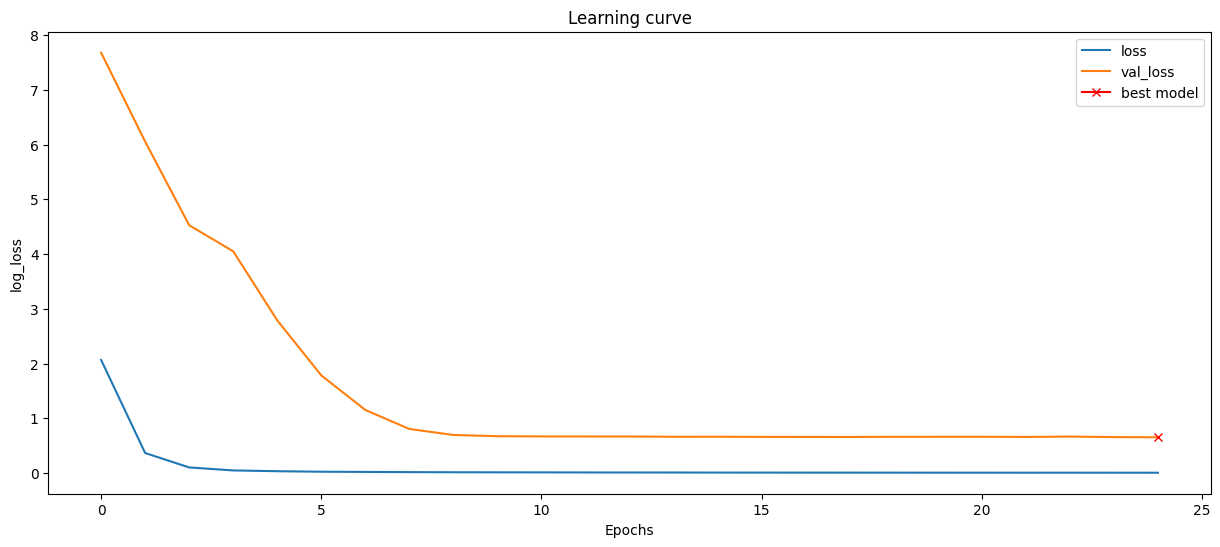

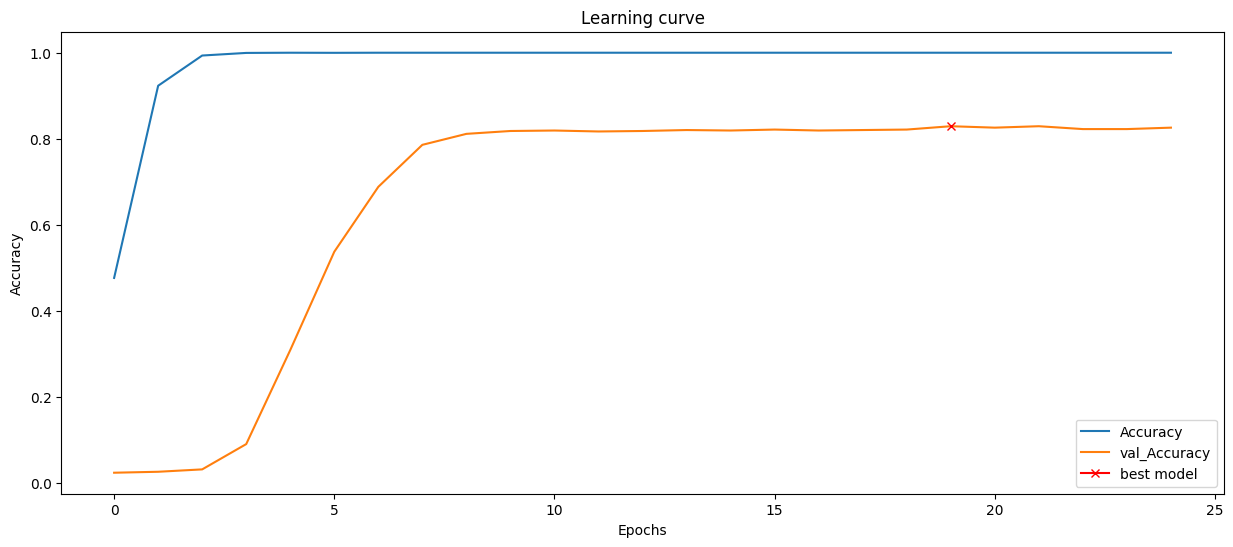

In [19]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(np.argmin(history.history["val_loss"]), np.min(history.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(history.history["accuracy"], label="Accuracy")
plt.plot(history.history["val_accuracy"], label="val_Accuracy")
plt.plot(np.argmax(history.history["val_accuracy"]), np.max(history.history["val_accuracy"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();